# SDK Download Final Analysis

This notebook analyzes `sdk_download_final` inside `developer_project.duckdb` as a product adoption and momentum signal for the Spring 2026 Industry Project.

Main goals:

- Validate data quality and coverage.
- Identify dominant products, sources, regions, and platforms.
- Surface recent product and country momentum.
- Recommend feature tables for downstream modeling and dashboards.

## Setup

In [1]:
from pathlib import Path

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

db_candidates = [
    Path("developer_project.duckdb"),
    Path("..") / "developer_project.duckdb",
]

DB_PATH = next((path for path in db_candidates if path.exists()), None)
if DB_PATH is None:
    raise FileNotFoundError("Could not find developer_project.duckdb in the current folder or parent folder.")

con = duckdb.connect(str(DB_PATH), read_only=True)
TABLE = "sdk_download_final"

print(f"Connected to: {DB_PATH.resolve()}")

Connected to: /Users/oliviachoi/Documents/GitHub/Spring2026_IndustryProject/developer_project.duckdb


In [2]:
def q(sql: str) -> pd.DataFrame:
    return con.execute(sql).fetchdf()


def show(title: str, sql: str, max_rows: int = 30) -> pd.DataFrame:
    display(Markdown(f"### {title}"))
    df = q(sql)
    display(df.head(max_rows))
    return df


def fmt_millions(value: float) -> str:
    return f"{value / 1_000_000:,.2f}M"


def fmt_billions(value: float) -> str:
    return f"{value / 1_000_000_000:,.2f}B"

## Schema And Core Coverage

In [3]:
schema = show(
    "Schema",
    f"DESCRIBE {TABLE};",
)

core_quality = show(
    "Core quality and coverage",
    f"""
    SELECT
      COUNT(*) AS rows,
      SUM(download_count) AS total_download_count,
      MIN(download_date) AS first_download_date,
      MAX(download_date) AS last_download_date,
      COUNT_IF(download_date IS NULL) AS null_download_date_rows,
      COUNT_IF(download_count IS NULL) AS null_download_count_rows,
      COUNT_IF(download_count < 0) AS negative_download_count_rows,
      COUNT_IF(download_count = 0) AS zero_download_count_rows,
      COUNT(DISTINCT product_name) AS distinct_products,
      COUNT(DISTINCT sdk_name) AS distinct_sdk_names,
      COUNT(DISTINCT country) AS distinct_countries,
      COUNT(DISTINCT operating_system) AS distinct_operating_systems,
      COUNT(DISTINCT file_type) AS distinct_file_types,
      COUNT(DISTINCT source) AS distinct_sources
    FROM {TABLE};
    """,
)

### Schema

,column_name,column_type,null,key,default,extra
0,source,VARCHAR,YES,None,None,None
1,sdk_name,VARCHAR,YES,None,None,None
2,product_name,VARCHAR,YES,None,None,None
3,product_release,VARCHAR,YES,None,None,None
4,country,VARCHAR,YES,None,None,None
5,region,VARCHAR,YES,None,None,None
6,subregion,VARCHAR,YES,None,None,None
7,territory,VARCHAR,YES,None,None,None
8,zone,VARCHAR,YES,None,None,None
9,download_date,DATE,YES,None,None,None


### Core quality and coverage

,rows,total_download_count,first_download_date,last_download_date,null_download_date_rows,null_download_count_rows,negative_download_count_rows,zero_download_count_rows,distinct_products,distinct_sdk_names,distinct_countries,distinct_operating_systems,distinct_file_types,distinct_sources
0,93038213,"15,335,209,088.00",2020-01-01,2026-03-12,0.00,0.00,0.00,"1,490,971.00",1149,186,247,202,58,14


In [4]:
download_distribution = show(
    "Download count distribution",
    f"""
    SELECT
      MIN(download_count) AS min_download_count,
      QUANTILE_CONT(download_count, 0.01) AS p01,
      QUANTILE_CONT(download_count, 0.25) AS p25,
      QUANTILE_CONT(download_count, 0.50) AS p50,
      QUANTILE_CONT(download_count, 0.75) AS p75,
      QUANTILE_CONT(download_count, 0.95) AS p95,
      QUANTILE_CONT(download_count, 0.99) AS p99,
      MAX(download_count) AS max_download_count,
      AVG(download_count) AS avg_download_count
    FROM {TABLE}
    WHERE download_count IS NOT NULL;
    """,
)

### Download count distribution

100% ▕██████████████████████████████████████▏ (00:00:05.18 elapsed)     


,min_download_count,p01,p25,p50,p75,p95,p99,max_download_count,avg_download_count
0,0,0.00,1.00,2.00,8.00,115.00,"1,331.00",7589612,164.83


## Placeholder And Unknown Value Profile

The cleaned table has no SQL nulls in the important fields, but several columns use text placeholders such as `unknown`, `UNKNOWN`, or `null`. These should be treated as missing-like values during feature engineering.

In [5]:
placeholder_profile = show(
    "Unknown-ish values by important column",
    f"""
    WITH base AS (
      SELECT COUNT(*) AS n FROM {TABLE}
    ), u AS (
      SELECT 'country' AS col, COUNT_IF(LOWER(TRIM(country)) IN ('unknown','null','none','n/a','')) AS rows FROM {TABLE}
      UNION ALL SELECT 'region', COUNT_IF(LOWER(TRIM(region)) IN ('unknown','null','none','n/a','')) FROM {TABLE}
      UNION ALL SELECT 'subregion', COUNT_IF(LOWER(TRIM(subregion)) IN ('unknown','null','none','n/a','')) FROM {TABLE}
      UNION ALL SELECT 'territory', COUNT_IF(LOWER(TRIM(territory)) IN ('unknown','null','none','n/a','')) FROM {TABLE}
      UNION ALL SELECT 'zone', COUNT_IF(LOWER(TRIM(zone)) IN ('unknown','null','none','n/a','')) FROM {TABLE}
      UNION ALL SELECT 'operating_system', COUNT_IF(LOWER(TRIM(operating_system)) IN ('unknown','null','none','n/a','')) FROM {TABLE}
      UNION ALL SELECT 'file_type', COUNT_IF(LOWER(TRIM(file_type)) IN ('unknown','null','none','n/a','')) FROM {TABLE}
      UNION ALL SELECT 'os_distribution', COUNT_IF(LOWER(TRIM(os_distribution)) IN ('unknown','null','none','n/a','')) FROM {TABLE}
      UNION ALL SELECT 'architecture', COUNT_IF(LOWER(TRIM(architecture)) IN ('unknown','null','none','n/a','')) FROM {TABLE}
    )
    SELECT col, rows, ROUND(100.0 * rows / n, 2) AS pct_rows
    FROM u, base
    ORDER BY rows DESC;
    """,
)

### Unknown-ish values by important column

,col,rows,pct_rows
0,os_distribution,"88,308,962.00",94.92
1,architecture,"88,142,755.00",94.74
2,territory,"39,472,827.00",42.43
3,operating_system,"18,037,776.00",19.39
4,country,"1,254,777.00",1.35
5,region,"1,254,777.00",1.35
6,subregion,"1,254,777.00",1.35
7,zone,"1,254,777.00",1.35
8,file_type,"1,199,256.00",1.29


## Exact Duplicate Diagnostics

This check groups by every column, so it can take around a minute on the full table. Keep it on for the final run; turn it off for quick iteration.

In [6]:
RUN_HEAVY_DUPLICATE_CHECKS = True

if RUN_HEAVY_DUPLICATE_CHECKS:
    duplicate_summary = show(
        "Full-row duplicate summary",
        f"""
        WITH grouped AS (
          SELECT
            source, sdk_name, product_name, product_release, country, region, subregion, territory, zone,
            download_date, file_type, operating_system, os_distribution, architecture, kpi, download_count,
            COUNT(*) AS n
          FROM {TABLE}
          GROUP BY ALL
          HAVING COUNT(*) > 1
        ), total AS (
          SELECT SUM(download_count) AS total_downloads FROM {TABLE}
        )
        SELECT
          COUNT(*) AS duplicate_groups,
          SUM(n) AS rows_in_duplicate_groups,
          SUM(n - 1) AS duplicate_rows_beyond_first,
          MAX(n) AS max_copies_of_same_row,
          SUM((n - 1) * download_count) AS duplicate_extra_downloads,
          ROUND(100.0 * SUM((n - 1) * download_count) / ANY_VALUE(total_downloads), 4) AS duplicate_extra_pct_of_downloads
        FROM grouped, total;
        """,
    )
else:
    duplicate_summary = pd.DataFrame()
    print("Duplicate diagnostics skipped. Set RUN_HEAVY_DUPLICATE_CHECKS = True to run them.")

### Full-row duplicate summary

100% ▕██████████████████████████████████████▏ (00:00:20.78 elapsed)     


,duplicate_groups,rows_in_duplicate_groups,duplicate_rows_beyond_first,max_copies_of_same_row,duplicate_extra_downloads,duplicate_extra_pct_of_downloads
0,277810,"555,866.00","278,056.00",4,"1,261,852.00",0.01


## Product Adoption Concentration

In [7]:
top_products = show(
    "Top products by total downloads",
    f"""
    SELECT
      product_name,
      COUNT(*) AS rows,
      SUM(download_count) AS downloads,
      COUNT(DISTINCT sdk_name) AS sdk_names,
      COUNT(DISTINCT country) AS countries,
      MIN(download_date) AS first_date,
      MAX(download_date) AS last_date
    FROM {TABLE}
    GROUP BY product_name
    ORDER BY downloads DESC NULLS LAST
    LIMIT 20;
    """,
)

concentration = show(
    "Top product concentration",
    f"""
    WITH total AS (SELECT SUM(download_count) AS total_downloads FROM {TABLE}),
    ranked AS (
      SELECT
        product_name,
        SUM(download_count) AS downloads,
        ROW_NUMBER() OVER (ORDER BY SUM(download_count) DESC) AS rn
      FROM {TABLE}
      GROUP BY product_name
    )
    SELECT
      SUM(CASE WHEN rn <= 5 THEN downloads ELSE 0 END) AS top_5_downloads,
      ROUND(100.0 * SUM(CASE WHEN rn <= 5 THEN downloads ELSE 0 END) / ANY_VALUE(total_downloads), 2) AS top_5_pct,
      SUM(CASE WHEN rn <= 10 THEN downloads ELSE 0 END) AS top_10_downloads,
      ROUND(100.0 * SUM(CASE WHEN rn <= 10 THEN downloads ELSE 0 END) / ANY_VALUE(total_downloads), 2) AS top_10_pct,
      SUM(CASE WHEN rn <= 20 THEN downloads ELSE 0 END) AS top_20_downloads,
      ROUND(100.0 * SUM(CASE WHEN rn <= 20 THEN downloads ELSE 0 END) / ANY_VALUE(total_downloads), 2) AS top_20_pct
    FROM ranked, total;
    """,
)

### Top products by total downloads

,product_name,rows,downloads,sdk_names,countries,first_date,last_date
0,torch,5607273,"1,514,032,253.00",1,243,2020-01-01,2026-03-09
1,tensorflow,9207348,"1,228,434,719.00",1,238,2020-01-01,2026-03-09
2,nvidia-nccl-cu12,1015190,"708,909,487.00",1,235,2022-11-16,2026-03-09
3,triton,1133052,"672,785,669.00",1,236,2020-01-01,2026-03-09
4,nvidia-cublas-cu12,1000698,"647,343,188.00",1,235,2022-11-16,2026-03-09
5,nvidia-cusparse-cu12,938821,"631,732,103.00",1,235,2022-11-16,2026-03-09
6,nvidia-cudnn-cu12,969238,"626,878,054.00",1,235,2022-11-16,2026-03-09
7,nvidia-cufft-cu12,914229,"614,503,081.00",1,235,2022-11-16,2026-03-09
8,nvidia-cuda-nvrtc-cu12,936717,"611,498,047.00",1,235,2022-11-16,2026-03-09
9,nvidia-cusolver-cu12,872610,"610,837,266.00",1,235,2022-11-16,2026-03-09


### Top product concentration

,top_5_downloads,top_5_pct,top_10_downloads,top_10_pct,top_20_downloads,top_20_pct
0,"4,771,505,316.00",31.11,"7,866,953,867.00",51.30,"12,098,917,230.00",78.90


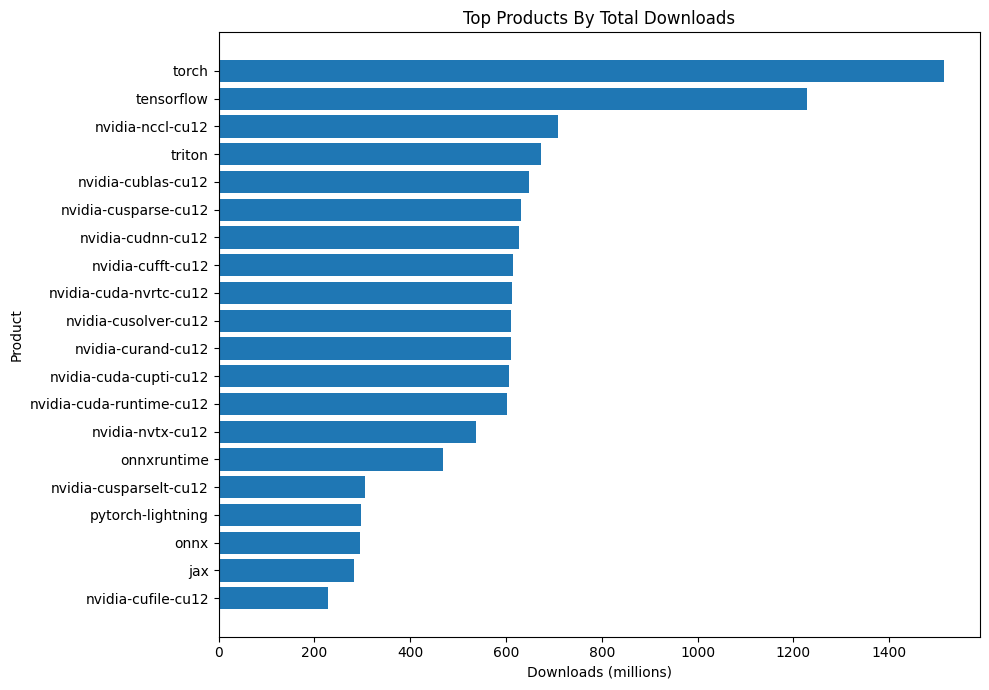

In [8]:
plot_df = top_products.sort_values("downloads", ascending=True).copy()

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(plot_df["product_name"], plot_df["downloads"] / 1_000_000)
ax.set_title("Top Products By Total Downloads")
ax.set_xlabel("Downloads (millions)")
ax.set_ylabel("Product")
plt.tight_layout()
plt.show()

## Source, Geography, And Platform Mix

In [9]:
source_share = show(
    "Source share of downloads",
    f"""
    WITH total AS (SELECT SUM(download_count) AS total_downloads FROM {TABLE})
    SELECT
      source,
      SUM(download_count) AS downloads,
      ROUND(100.0 * SUM(download_count) / ANY_VALUE(total_downloads), 2) AS pct_downloads,
      COUNT(DISTINCT product_name) AS products,
      MIN(download_date) AS first_date,
      MAX(download_date) AS last_date
    FROM {TABLE}, total
    GROUP BY source
    ORDER BY downloads DESC NULLS LAST;
    """,
)

region_share = show(
    "Regional distribution",
    f"""
    SELECT
      region,
      COUNT(*) AS rows,
      SUM(download_count) AS downloads,
      COUNT(DISTINCT country) AS countries,
      COUNT(DISTINCT product_name) AS products
    FROM {TABLE}
    GROUP BY region
    ORDER BY downloads DESC NULLS LAST;
    """,
)

country_share = show(
    "Top countries",
    f"""
    WITH total AS (SELECT SUM(download_count) AS total_downloads FROM {TABLE})
    SELECT
      country,
      region,
      SUM(download_count) AS downloads,
      ROUND(100.0 * SUM(download_count) / ANY_VALUE(total_downloads), 2) AS pct_downloads,
      COUNT(DISTINCT product_name) AS products,
      MIN(download_date) AS first_date,
      MAX(download_date) AS last_date
    FROM {TABLE}, total
    GROUP BY country, region
    ORDER BY downloads DESC NULLS LAST
    LIMIT 25;
    """,
)

### Source share of downloads

,source,downloads,pct_downloads,products,first_date,last_date
0,pypi,"14,496,602,575.00",94.53,264,2020-01-01,2026-03-09
1,github,"288,650,695.00",1.88,226,2020-07-13,2026-03-10
2,cdn,"278,722,121.00",1.82,217,2020-01-01,2026-03-11
3,ngc,"106,683,990.00",0.70,244,2020-03-09,2026-03-12
4,dockerhub,"87,117,667.00",0.57,25,2020-01-01,2026-03-12
5,conda,"45,664,750.00",0.30,74,2020-01-01,2026-03-12
6,cdn - pypi,"23,643,951.00",0.15,24,2023-04-18,2026-03-11
7,huggingface,"5,801,805.00",0.04,77,2024-11-08,2026-03-11
8,cdn - azure,"875,590.00",0.01,4,2024-10-16,2026-03-09
9,cdn - apt,"798,424.00",0.01,3,2023-10-21,2026-03-11


### Regional distribution

,region,rows,downloads,countries,products
0,nala,17804811,"11,040,877,074.00",56,726
1,emea,43646116,"2,252,380,358.00",137,698
2,apac,30332509,"1,593,348,357.00",53,687
3,unknown,1254777,"448,603,299.00",1,925


### Top countries

,country,region,downloads,pct_downloads,products,first_date,last_date
0,US,nala,"10,795,660,484.00",70.40,726,2020-01-01,2026-03-12
1,UNKNOWN,unknown,"448,603,299.00",2.93,925,2020-01-01,2026-03-12
2,DE,emea,"430,704,814.00",2.81,649,2020-01-01,2026-03-12
3,SG,apac,"413,890,169.00",2.70,600,2020-01-01,2026-03-12
4,NL,emea,"410,364,666.00",2.68,559,2020-01-01,2026-03-11
5,IE,emea,"394,383,041.00",2.57,556,2020-01-01,2026-03-12
6,IN,apac,"231,383,788.00",1.51,642,2020-01-01,2026-03-12
7,JP,apac,"214,142,223.00",1.40,651,2020-01-01,2026-03-12
8,CN,apac,"205,354,395.00",1.34,629,2020-01-01,2026-03-12
9,GB,emea,"194,103,832.00",1.27,646,2020-01-01,2026-03-12


In [10]:
platform_mix = show(
    "Platform distribution by operating system",
    f"""
    SELECT
      COALESCE(NULLIF(TRIM(operating_system), ''), '[missing]') AS operating_system,
      COUNT(*) AS rows,
      SUM(download_count) AS downloads,
      COUNT(DISTINCT product_name) AS products
    FROM {TABLE}
    GROUP BY 1
    ORDER BY downloads DESC NULLS LAST
    LIMIT 30;
    """,
)

file_type_mix = show(
    "File type distribution",
    f"""
    SELECT
      COALESCE(NULLIF(TRIM(file_type), ''), '[missing]') AS file_type,
      COUNT(*) AS rows,
      SUM(download_count) AS downloads,
      COUNT(DISTINCT product_name) AS products
    FROM {TABLE}
    GROUP BY 1
    ORDER BY downloads DESC NULLS LAST
    LIMIT 30;
    """,
)

### Platform distribution by operating system

,operating_system,rows,downloads,products
0,linux,37130704,"13,683,035,036.00",391
1,unknown,17946361,"975,649,983.00",1006
2,windows,24161804,"461,879,362.00",357
3,darwin,8695657,"135,877,746.00",264
4,linux x86,2947007,"63,837,914.00",11
5,linux arm,221358,"2,486,694.00",10
6,manualinput,501,"1,957,367.00",163
7,all,314623,"1,385,135.00",46
8,ubuntu 1804 x86_64,183204,"1,091,083.00",1
9,null,91415,"1,035,800.00",8


### File type distribution

,file_type,rows,downloads,products
0,package,71442184,"14,548,273,898.00",417
1,repository,175664,"288,650,695.00",226
2,container,4180223,"193,422,773.00",130
3,installer - kpi,9508317,"111,420,498.00",166
4,installer,1876963,"87,503,252.00",41
5,unknown,1199133,"51,001,440.00",37
6,whl,1089181,"26,178,448.00",26
7,installer-kpi,1109180,"8,773,445.00",4
8,video,192927,"7,180,323.00",5
9,installer - kpi-repo,81346,"4,214,595.00",1


## Monthly Trend And Recent Momentum

In [11]:
monthly_trend = show(
    "Monthly trend since 2024, excluding partial latest month",
    f"""
    WITH monthly AS (
      SELECT
        DATE_TRUNC('month', download_date) AS month,
        SUM(download_count) AS downloads,
        COUNT(*) AS rows,
        COUNT(DISTINCT product_name) AS active_products,
        COUNT(DISTINCT country) AS active_countries
      FROM {TABLE}
      WHERE download_date >= DATE '2024-01-01'
        AND download_date < DATE_TRUNC('month', (SELECT MAX(download_date) FROM {TABLE}))
      GROUP BY 1
    ), with_lag AS (
      SELECT
        month,
        downloads,
        rows,
        active_products,
        active_countries,
        LAG(downloads) OVER (ORDER BY month) AS prev_downloads
      FROM monthly
    )
    SELECT
      month,
      downloads,
      downloads - prev_downloads AS mom_abs_change,
      ROUND(100.0 * (downloads - prev_downloads) / NULLIF(prev_downloads, 0), 2) AS mom_pct_change,
      rows,
      active_products,
      active_countries
    FROM with_lag
    ORDER BY month;
    """,
    max_rows=60,
)

### Monthly trend since 2024, excluding partial latest month

,month,downloads,mom_abs_change,mom_pct_change,rows,active_products,active_countries
0,2024-01-01,"178,400,059.00",NaN,NaN,1426833,511,226
1,2024-02-01,"193,947,336.00","15,547,277.00",8.71,1391777,504,224
2,2024-03-01,"260,424,044.00","66,476,708.00",34.28,1578078,517,229
3,2024-04-01,"273,454,740.00","13,030,696.00",5.00,1574271,530,226
4,2024-05-01,"280,436,801.00","6,982,061.00",2.55,1615091,537,224
5,2024-06-01,"272,860,738.00","-7,576,063.00",-2.70,1577056,544,228
6,2024-07-01,"285,540,495.00","12,679,757.00",4.65,1708130,567,230
7,2024-08-01,"306,619,348.00","21,078,853.00",7.38,1766085,577,225
8,2024-09-01,"298,285,614.00","-8,333,734.00",-2.72,1809608,585,227
9,2024-10-01,"331,231,444.00","32,945,830.00",11.05,2150129,595,231


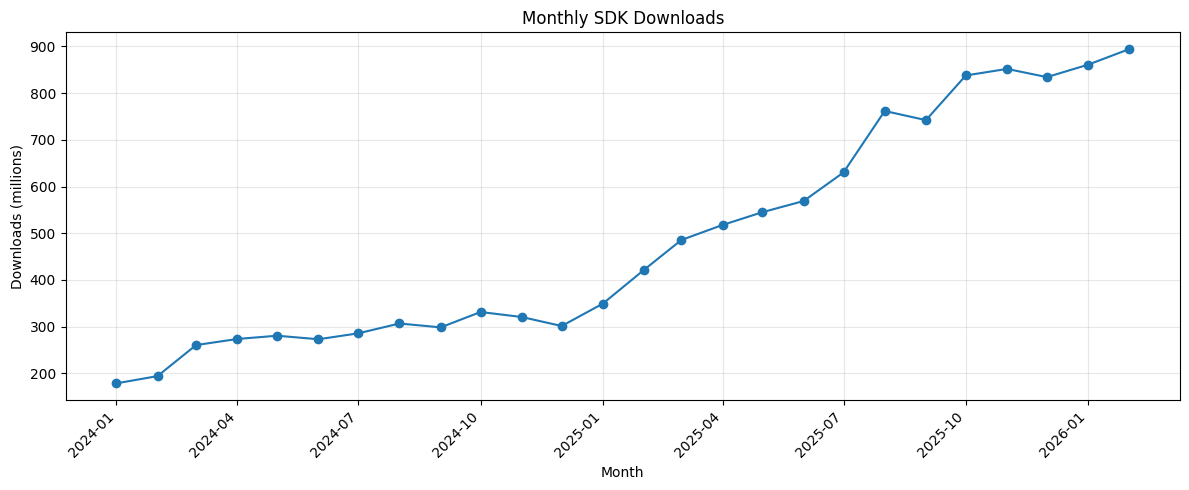

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_trend["month"], monthly_trend["downloads"] / 1_000_000, marker="o")
ax.set_title("Monthly SDK Downloads")
ax.set_xlabel("Month")
ax.set_ylabel("Downloads (millions)")
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [13]:
recent_growth_products = show(
    "Products with strongest recent 90-day growth vs prior 90 days",
    f"""
    WITH bounds AS (
      SELECT MAX(download_date) AS max_date FROM {TABLE}
    ), product_windows AS (
      SELECT
        product_name,
        SUM(CASE WHEN download_date > max_date - INTERVAL 90 DAY THEN download_count ELSE 0 END) AS recent_90d_downloads,
        SUM(CASE WHEN download_date <= max_date - INTERVAL 90 DAY
                  AND download_date > max_date - INTERVAL 180 DAY THEN download_count ELSE 0 END) AS prior_90d_downloads,
        COUNT(DISTINCT CASE WHEN download_date > max_date - INTERVAL 90 DAY THEN country END) AS recent_90d_countries
      FROM {TABLE}, bounds
      GROUP BY product_name
    )
    SELECT
      product_name,
      recent_90d_downloads,
      prior_90d_downloads,
      recent_90d_downloads - prior_90d_downloads AS abs_growth,
      CASE WHEN prior_90d_downloads > 0 THEN recent_90d_downloads::DOUBLE / prior_90d_downloads END AS growth_ratio,
      recent_90d_countries
    FROM product_windows
    WHERE recent_90d_downloads >= 10000
    ORDER BY abs_growth DESC NULLS LAST
    LIMIT 20;
    """,
)

recent_decline_products = show(
    "Products with largest recent 90-day declines vs prior 90 days",
    f"""
    WITH bounds AS (
      SELECT MAX(download_date) AS max_date FROM {TABLE}
    ), product_windows AS (
      SELECT
        product_name,
        SUM(CASE WHEN download_date > max_date - INTERVAL 90 DAY THEN download_count ELSE 0 END) AS recent_90d_downloads,
        SUM(CASE WHEN download_date <= max_date - INTERVAL 90 DAY
                  AND download_date > max_date - INTERVAL 180 DAY THEN download_count ELSE 0 END) AS prior_90d_downloads
      FROM {TABLE}, bounds
      GROUP BY product_name
    )
    SELECT
      product_name,
      recent_90d_downloads,
      prior_90d_downloads,
      recent_90d_downloads - prior_90d_downloads AS abs_growth,
      CASE WHEN prior_90d_downloads > 0 THEN recent_90d_downloads::DOUBLE / prior_90d_downloads END AS growth_ratio
    FROM product_windows
    WHERE prior_90d_downloads >= 10000
    ORDER BY abs_growth ASC NULLS LAST
    LIMIT 20;
    """,
)

### Products with strongest recent 90-day growth vs prior 90 days

,product_name,recent_90d_downloads,prior_90d_downloads,abs_growth,growth_ratio,recent_90d_countries
0,cuda-bindings,"42,825,796.00","5,117,841.00","37,707,955.00",8.37,218
1,nvidia-nvshmem-cu12,"65,387,463.00","34,732,706.00","30,654,757.00",1.88,225
2,sglang,"29,956,992.00","6,371,230.00","23,585,762.00",4.70,144
3,onnxruntime,"87,044,819.00","74,810,503.00","12,234,316.00",1.16,231
4,nvidia-cufile-cu12,"81,804,544.00","71,841,817.00","9,962,727.00",1.14,224
5,cusparselt pypi,"8,025,973.00","969,912.00","7,056,061.00",8.27,191
6,nvidia-cutlass-dsl,"6,828,182.00","1,740,046.00","5,088,136.00",3.92,184
7,jax,"43,121,362.00","38,926,408.00","4,194,954.00",1.11,212
8,nvidia-cusparselt-cu12,"92,468,775.00","88,886,907.00","3,581,868.00",1.04,225
9,nvidia-nccl-cu12,"154,225,977.00","150,718,704.00","3,507,273.00",1.02,226


### Products with largest recent 90-day declines vs prior 90 days

,product_name,recent_90d_downloads,prior_90d_downloads,abs_growth,growth_ratio
0,torch,"198,912,791.00","217,413,723.00","-18,500,932.00",0.91
1,tensorflow,"62,086,451.00","76,777,769.00","-14,691,318.00",0.81
2,nvidia-cudnn-cu12,"115,561,841.00","122,177,866.00","-6,616,025.00",0.95
3,nvidia-cuda-cupti-cu12,"114,161,816.00","120,177,198.00","-6,015,382.00",0.95
4,nvidia-cusolver-cu12,"116,185,661.00","122,042,339.00","-5,856,678.00",0.95
5,nvidia-curand-cu12,"115,627,654.00","121,001,402.00","-5,373,748.00",0.96
6,nvidia-cufft-cu12,"116,456,339.00","121,252,728.00","-4,796,389.00",0.96
7,pytorch-lightning,"28,027,080.00","32,778,175.00","-4,751,095.00",0.86
8,triton,"121,215,990.00","125,286,365.00","-4,070,375.00",0.97
9,nvidia-cuda-nvrtc-cu12,"116,706,217.00","120,700,499.00","-3,994,282.00",0.97


In [14]:
country_growth = show(
    "Recent 90-day country growth vs prior 90 days",
    f"""
    WITH bounds AS (
      SELECT MAX(download_date) AS max_date FROM {TABLE}
    ), country_windows AS (
      SELECT
        country,
        region,
        SUM(CASE WHEN download_date > max_date - INTERVAL 90 DAY THEN download_count ELSE 0 END) AS recent_90d_downloads,
        SUM(CASE WHEN download_date <= max_date - INTERVAL 90 DAY
                  AND download_date > max_date - INTERVAL 180 DAY THEN download_count ELSE 0 END) AS prior_90d_downloads,
        COUNT(DISTINCT CASE WHEN download_date > max_date - INTERVAL 90 DAY THEN product_name END) AS recent_products
      FROM {TABLE}, bounds
      GROUP BY country, region
    )
    SELECT
      country,
      region,
      recent_90d_downloads,
      prior_90d_downloads,
      recent_90d_downloads - prior_90d_downloads AS abs_growth,
      CASE WHEN prior_90d_downloads > 0 THEN recent_90d_downloads::DOUBLE / prior_90d_downloads END AS growth_ratio,
      recent_products
    FROM country_windows
    WHERE recent_90d_downloads >= 10000
    ORDER BY abs_growth DESC NULLS LAST
    LIMIT 20;
    """,
)

### Recent 90-day country growth vs prior 90 days

,country,region,recent_90d_downloads,prior_90d_downloads,abs_growth,growth_ratio,recent_products
0,US,nala,"1,855,852,628.00","1,773,134,161.00","82,718,467.00",1.05,619
1,CA,nala,"37,775,970.00","24,964,118.00","12,811,852.00",1.51,474
2,BD,apac,"9,642,635.00","497,918.00","9,144,717.00",19.37,289
3,SG,apac,"54,243,929.00","46,016,552.00","8,227,377.00",1.18,482
4,UNKNOWN,unknown,"49,519,557.00","42,399,157.00","7,120,400.00",1.17,707
5,HK,apac,"22,498,362.00","16,207,872.00","6,290,490.00",1.39,518
6,FI,emea,"13,247,990.00","8,984,357.00","4,263,633.00",1.47,437
7,FR,emea,"22,721,384.00","19,081,996.00","3,639,388.00",1.19,485
8,AU,apac,"16,349,840.00","12,899,207.00","3,450,633.00",1.27,436
9,BE,emea,"11,755,259.00","9,137,071.00","2,618,188.00",1.29,343


## Feature Engineering Starter Queries

These queries are designed to produce product-level adoption features without treating SDK downloads as developer-level behavior.

In [15]:
product_month_features = show(
    "Product-month adoption feature sample",
    f"""
    WITH deduped AS (
      SELECT DISTINCT * FROM {TABLE}
    ), product_month AS (
      SELECT
        DATE_TRUNC('month', download_date) AS month,
        product_name,
        SUM(download_count) AS downloads,
        COUNT(*) AS rows,
        COUNT(DISTINCT country) AS active_countries,
        COUNT(DISTINCT source) AS active_sources,
        COUNT(DISTINCT operating_system) AS operating_system_count,
        COUNT(DISTINCT file_type) AS file_type_count
      FROM deduped
      GROUP BY 1, 2
    ), with_growth AS (
      SELECT
        *,
        LAG(downloads, 1) OVER (PARTITION BY product_name ORDER BY month) AS downloads_prev_month,
        AVG(downloads) OVER (
          PARTITION BY product_name
          ORDER BY month
          ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
        ) AS downloads_trailing_3m_avg
      FROM product_month
    )
    SELECT
      *,
      downloads - downloads_prev_month AS mom_abs_growth,
      CASE WHEN downloads_prev_month > 0 THEN downloads::DOUBLE / downloads_prev_month END AS mom_growth_ratio
    FROM with_growth
    ORDER BY month DESC, downloads DESC
    LIMIT 50;
    """,
    max_rows=50,
)

### Product-month adoption feature sample

100% ▕██████████████████████████████████████▏ (00:00:29.92 elapsed)     


,month,product_name,downloads,rows,active_countries,active_sources,operating_system_count,file_type_count,downloads_prev_month,downloads_trailing_3m_avg,mom_abs_growth,mom_growth_ratio
0,2026-03-01,torch,"23,294,311.00",48546,224,1,6,1,"68,216,288.00","53,655,437.33","-44,921,977.00",0.34
1,2026-03-01,nvidia-nccl-cu12,"19,231,101.00",20029,209,1,6,1,"54,163,918.00","41,725,042.00","-34,932,817.00",0.36
2,2026-03-01,triton,"14,819,866.00",19495,205,1,6,1,"43,139,968.00","33,082,522.00","-28,320,102.00",0.34
3,2026-03-01,nvidia-cublas-cu12,"14,566,190.00",15650,206,1,7,1,"43,724,229.00","33,531,036.67","-29,158,039.00",0.33
4,2026-03-01,nvidia-cusparse-cu12,"14,158,818.00",15049,206,1,6,1,"42,328,546.00","32,594,739.00","-28,169,728.00",0.33
5,2026-03-01,nvidia-cudnn-cu12,"14,000,024.00",17418,206,1,6,1,"40,788,816.00","31,402,990.33","-26,788,792.00",0.34
6,2026-03-01,nvidia-cuda-nvrtc-cu12,"13,997,600.00",15247,206,1,6,1,"40,765,169.00","31,356,253.00","-26,767,569.00",0.34
7,2026-03-01,nvidia-cufft-cu12,"13,979,082.00",14833,205,1,6,1,"40,581,238.00","31,298,968.00","-26,602,156.00",0.34
8,2026-03-01,nvidia-curand-cu12,"13,964,810.00",14792,206,1,6,1,"40,333,179.00","31,056,953.00","-26,368,369.00",0.35
9,2026-03-01,nvidia-cusolver-cu12,"13,956,418.00",14604,205,1,6,1,"40,530,524.00","31,233,712.67","-26,574,106.00",0.34


## Interpretation

Use `sdk_download_final` as a product adoption and product momentum layer. It is useful for identifying which SDKs/products are growing, where adoption is concentrated, and which distribution sources dominate. It should not be joined to developer activity as if it identifies individual developers.

Recommended downstream features:

- `product_month`: downloads, active countries, active sources, source diversity, month-over-month growth.
- `product_country_month`: downloads, country share, first-seen month, recent 90-day growth.
- `source_product_month`: source-specific downloads and growth.
- `product_lifecycle`: first date, latest date, active months, peak month, recent 90-day downloads.
- `momentum_flags`: recent growth, recent decline, volatility, and spike indicators.